In [2]:
import tensorflow as tf 
from tensorflow import keras
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
data_set = keras.datasets.fashion_mnist
(X_train , y_train) , (X_test, y_test) = data_set.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 33s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 13s 3us/step


In [5]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [6]:
np.unique_counts(y_train)

UniqueCountsResult(values=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), counts=array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

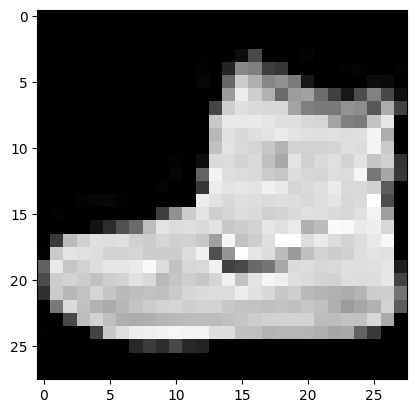

In [19]:
plt.imshow(X_train[0,:,:],cmap='gray')


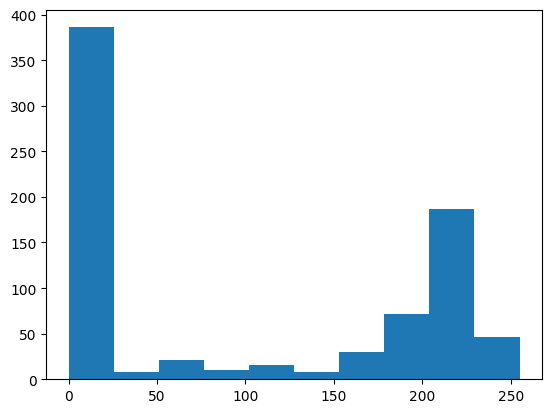

In [16]:
plt.hist(X_train[0, :, :].flatten(), bins=10)
plt.show()

In [20]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

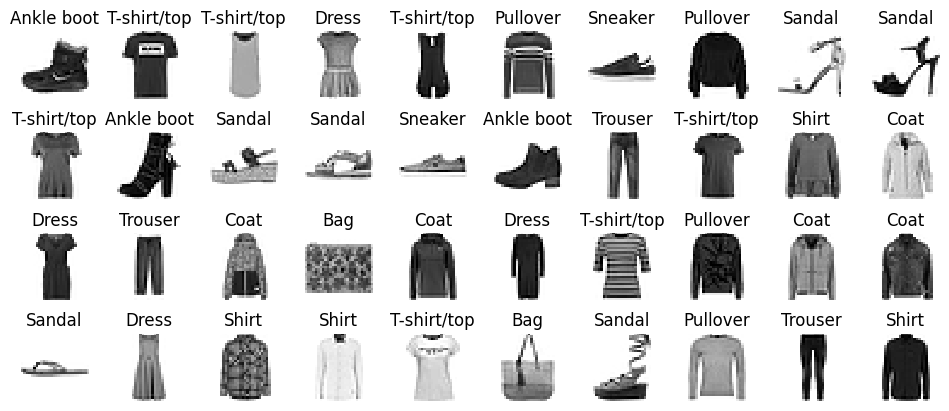

In [21]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [22]:
np.random.seed(42)

val_indices = []

for c in range(10):
    indices = np.where(y_train == c)[0]
    chosen = np.random.choice(indices, 500, replace=False)
    val_indices.extend(chosen)

val_indices = np.array(val_indices)

X_val = X_train[val_indices]
y_val = y_train[val_indices]

X_train = np.delete(X_train, val_indices, axis=0)
y_train = np.delete(y_train, val_indices, axis=0)

print(X_train.shape)
print(X_val.shape)
print(np.unique(y_val, return_counts=True))

(55000, 28, 28)
(5000, 28, 28)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([500, 500, 500, 500, 500, 500, 500, 500, 500, 500]))


In [23]:
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32')   / 255.0
X_test  = X_test.astype('float32')  / 255.0

In [29]:
model = keras.models.Sequential()
model.add(keras.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8264 - loss: 0.4811 - val_accuracy: 0.8544 - val_loss: 0.4008
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8669 - loss: 0.3626 - val_accuracy: 0.8638 - val_loss: 0.3619
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8795 - loss: 0.3252 - val_accuracy: 0.8756 - val_loss: 0.3415
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8863 - loss: 0.3067 - val_accuracy: 0.8762 - val_loss: 0.3322
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8934 - loss: 0.2851 - val_accuracy: 0.8758 - val_loss: 0.3422
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8987 - loss: 0.2712 - val_accuracy: 0.8784 - val_loss: 0.3287
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9038 - loss: 0.2582 - val_accuracy: 0.8786 - val_loss: 0.3324
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9058 - loss: 0

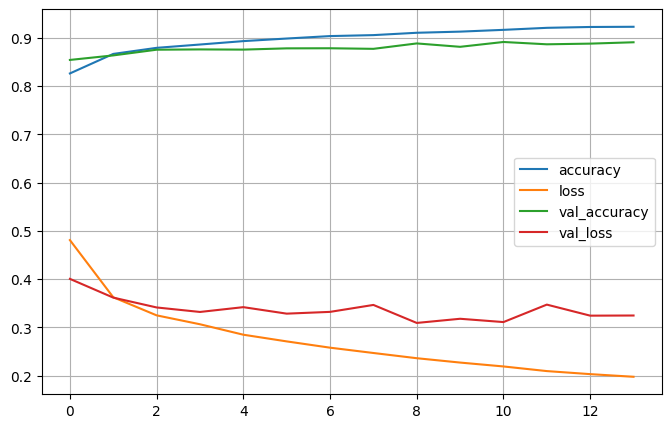

In [33]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8840 - loss: 0.3289
Test Accuracy: 0.8840000033378601


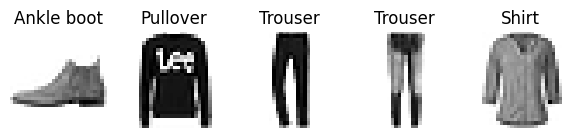

In [39]:
X_new =X_test[:5,:,:]

plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()